# **Datalab II Sprint 3 2025 - 2026**
**Plaats:** De Haagse Hogenschool, ADS & AI<br>
**Auteurs:** M. Kilinc, D. Hoogenbosch, J. Wolthuis, S. Slingerland, L. van Hamersveld<br>
**Groep:** B2 <br>
**Coach:** Onur Tezel <br>
**Datum:** 31/03/2026


| Naam  | Studentnummer |
|-------|---------------|
| Lucas | 25076116      |
| Sandro| 25154370      |
| Mehmet| 25135007      |
| Julius| 25090216      |
| Dylan | 25118498      |
---

## **Inhoudsopgave**
1. [Imports & Configuratie](#1)
2. [Data inladen](#2)
3. [Data Exploration met SQL](#3)
4. [Onderzoeken Teameigenschappen](#4)

---
<a id='1'></a>
## **1. Imports & Configuratie**

In [18]:
# Imports
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
from scipy.stats import pearsonr, f_oneway

In [19]:
# Via deze functie in pandas zorgen we ervoor dat we de DataFrames volledig kunnen weergeven in de cell
pd.set_option('display.max_rows', 200)

In [20]:
# Herbruikbare functie om een SQL-query uit te voeren en het resultaat te tonen
def voer_query_uit(query, conn, toon=True):
    """Voert een SQL-query uit en geeft het resultaat terug als DataFrame.
    
    Parameters:
        query (str): De SQL-query om uit te voeren.
        conn: De database connectie.
        toon (bool): Als True wordt het DataFrame getoond. Standaard True.
    """
    df = pd.read_sql(query, conn)
    if toon:
        display(df)
    return df

---
<a id='2'></a>
## **2. Data inladen**
In de onderstaande kolommen laden we de data op dezelfde manier als de vorige keer, namelijk via de Kaggle API. <br> 
Hieronder vind je een uitleg over het gebruik en een referentie.



### **2.1 Gebruik van de Kaggle API** 
We gebruiken de Kaggle API om de data lokaal op te slaan en dit hoeft slechts eenmalig te gebeuren.<br>Download de API-sleutel uit onze GitHub-repository en plaats deze in de map C:\Users\<Jouw_gebruikersnaam>\.kaggle. <br>

Raadpleeg voor verdere instructies de officiële documentatie op https://www.kaggle.com/docs/api.<br>
Verwijder eventueel het # in het script, voer de pip install en de data-import uit en je bent klaar om de data lokaal te gebruiken.


In [21]:
# %pip install kaggle 
import kaggle 
kaggle.api.authenticate()
kaggle.api.dataset_download_files("hugomathien/soccer", path='.', unzip=True)

Dataset URL: https://www.kaggle.com/datasets/hugomathien/soccer


In [22]:
# Maak een verbinding met de SQLite-database "database.sqlite"
connection = sqlite3.connect("database.sqlite")

# Voer een SQL-query uit om alle gegevens uit de tabel 'Match' op te halen, het resultaat wordt ingelezen als pandas DataFrame
df = pd.read_sql("""
    
    SELECT *  
        FROM Match 
                 
    """, 
    connection)

---
<a id='3'></a>
## **3. Data Exploration met SQL** 
Ter referentie: op basis van het vorige notebook hebben we alle databaserelaties visueel in kaart gebracht met een dbdiagram.io-schema.

![Alternatieve tekst](Diagram.png)

---
### 3.1 Aantal gespeelde wedstrijden per seizoen

In [23]:
AZ_API_ID = 10229
AZ_FIFA_ID = 1906

# Query
query  = f"""

SELECT season, COUNT(*) AS aantal_gespeelde_wedstrijden
FROM Match

WHERE home_team_api_id = {AZ_API_ID}
   OR away_team_api_id = {AZ_API_ID}

GROUP BY season
ORDER BY season;

"""
# Opslaan data uit query in DataFrame en tonen
df = voer_query_uit(query, connection)

# Printen samenvatting ondervindingen 
print(f'AZ alkmaar is sinds seizoen 1998/1999 onafgebroken in de Eredivisie een speelde: {df["aantal_gespeelde_wedstrijden"].sum()} wedstrijden')


,season,aantal_gespeelde_wedstrijden
0,2008/2009,34
1,2009/2010,34
2,2010/2011,34
3,2011/2012,34
4,2012/2013,34
5,2013/2014,34
6,2014/2015,34
7,2015/2016,34


AZ alkmaar is sinds seizoen 1998/1999 onafgebroken in de Eredivisie een speelde: 272 wedstrijden


---
### 3.2 Aantal gespeelde wedstrijden kalender jaar 2010

In [24]:
# In deze query wordt gebruik gemaakt van strftime (string format time) 
# Deze functie converteert datum en tijdobjecten naar leesbare tekenreeksen op basis van specifieke opmaakcodes

# Query
query  = f"""

SELECT season, COUNT(*) AS gespeelde_wedstrijden
FROM Match

WHERE (home_team_api_id = {AZ_API_ID} OR 
away_team_api_id = {AZ_API_ID})
AND strftime('%Y', date) = '2010' 

GROUP BY season
ORDER BY season;

"""

# Opslaan data uit query in DataFrame en tonen
df = voer_query_uit(query, connection)

# Printen samenvatting ondervindingen 
print(f'In het kalender jaar 2010 speelde AZ: {df["gespeelde_wedstrijden"].sum()} wedstrijden')

,season,gespeelde_wedstrijden
0,2009/2010,16
1,2010/2011,18


In het kalender jaar 2010 speelde AZ: 34 wedstrijden


---
### 3.3 Punten per seizoen & eindklassering

In [25]:
# Ik gebruik hier UNION ALL deze functie stapelt rijen van tabellen op elkaar inclusief dubbele records
Eredivisie_id = 13274

query = f"""
SELECT
    T.team_long_name AS Team,
    S.season,
    SUM(S.punten) AS totaal_punten
FROM (
    SELECT
        season,
        home_team_api_id AS team_api_id,
        CASE
            WHEN home_team_goal > away_team_goal THEN 3
            WHEN home_team_goal = away_team_goal THEN 1
            ELSE 0
        END AS punten
    FROM Match
    WHERE league_id = {Eredivisie_id}

    UNION ALL

    SELECT
        season,
        away_team_api_id AS team_api_id,
        CASE
            WHEN away_team_goal > home_team_goal THEN 3
            WHEN away_team_goal = home_team_goal THEN 1
            ELSE 0
        END AS punten

    FROM Match
    WHERE league_id = {Eredivisie_id}
) AS S

JOIN Team AS T ON S.team_api_id = T.team_api_id
GROUP BY S.season, S.team_api_id, T.team_long_name
ORDER BY S.season DESC, totaal_punten DESC;
"""

# Opslaan data uit query in DataFrame
df_2 = voer_query_uit(query, connection, toon=False)

# DataFrame eerste 10 rijen want er zijn veel rijen in dit DataFrame
display(df_2.head(10))

,Team,season,totaal_punten
0,PSV,2015/2016,84
1,Ajax,2015/2016,82
2,Feyenoord,2015/2016,63
3,AZ,2015/2016,59
4,FC Utrecht,2015/2016,53
5,Heracles Almelo,2015/2016,51
6,FC Groningen,2015/2016,50
7,PEC Zwolle,2015/2016,48
8,Vitesse,2015/2016,46
9,N.E.C.,2015/2016,46


---
### 3.4 Eindklassering AZ per seizoen

In [26]:
# Rangschikking per seizoen bepalen op basis van totaal punten
df_2['klassering'] = df_2.groupby('season')['totaal_punten'].rank(ascending=False, method='min').astype(int)

# Eindklassering van AZ Alkmaar per seizoen weergeven
df_az_klassering = df_2[df_2['Team'] == 'AZ'][['season', 'totaal_punten', 'klassering']].sort_values('season').reset_index(drop=True)
display(df_az_klassering)

# Printen samenvatting ondervindingen
print(f'AZ Alkmaar eindigde gemiddeld op plaats {df_az_klassering["klassering"].mean():.1f} in de Eredivisie')

,season,totaal_punten,klassering
0,2008/2009,80,1
1,2009/2010,62,5
2,2010/2011,59,4
3,2011/2012,65,4
4,2012/2013,39,10
5,2013/2014,47,8
6,2014/2015,62,3
7,2015/2016,59,4


AZ Alkmaar eindigde gemiddeld op plaats 4.9 in de Eredivisie


---
<a id='4'></a>
## **4. Onderzoeken Teameigenschappen**

---
### 4.1 Teameigenschappen samenvoegen

In [27]:
# query om teameigenschappen te selecteren en te groeperen op teamnaam
query = """
SELECT
    T.team_long_name AS Team,
    AVG(TA.buildUpPlaySpeed)            AS buildUpPlaySpeed,
    AVG(TA.buildUpPlayDribbling)        AS buildUpPlayDribbling,
    AVG(TA.buildUpPlayPassing)          AS buildUpPlayPassing,
    AVG(TA.chanceCreationPassing)       AS chanceCreationPassing,
    AVG(TA.chanceCreationCrossing)      AS chanceCreationCrossing,
    AVG(TA.chanceCreationShooting)      AS chanceCreationShooting,
    AVG(TA.defencePressure)             AS defencePressure,
    AVG(TA.defenceAggression)           AS defenceAggression,
    AVG(TA.defenceTeamWidth)            AS defenceTeamWidth
FROM Team_Attributes AS TA
JOIN Team AS T ON TA.team_api_id = T.team_api_id
GROUP BY T.team_long_name;
"""

# Opslaan data uit query in DataFrame
df_attrs = voer_query_uit(query, connection, toon=False)

# Samenvoegen met het punten DataFrame op teamnaam
df_merged = pd.merge(df_2, df_attrs, on='Team', how='inner')

# DataFrame met alle teameigenschappen en punten per team 
display(df_merged.head(10))

# Print grote van de samengevoegde DataFrame
print(f'Samengevoegd DataFrame: {len(df_merged)} rijen, {len(df_merged.columns)} kolommen')

,Team,season,totaal_punten,klassering,buildUpPlaySpeed,buildUpPlayDribbling,buildUpPlayPassing,chanceCreationPassing,chanceCreationCrossing,chanceCreationShooting,defencePressure,defenceAggression,defenceTeamWidth
0,PSV,2015/2016,84,1,52.333333,39.0,38.333333,50.166667,54.5,54.000000,43.833333,41.500000,48.833333
1,PSV,2014/2015,88,1,52.333333,39.0,38.333333,50.166667,54.5,54.000000,43.833333,41.500000,48.833333
2,PSV,2013/2014,59,4,52.333333,39.0,38.333333,50.166667,54.5,54.000000,43.833333,41.500000,48.833333
3,PSV,2012/2013,69,2,52.333333,39.0,38.333333,50.166667,54.5,54.000000,43.833333,41.500000,48.833333
4,PSV,2011/2012,69,3,52.333333,39.0,38.333333,50.166667,54.5,54.000000,43.833333,41.500000,48.833333
5,PSV,2010/2011,69,3,52.333333,39.0,38.333333,50.166667,54.5,54.000000,43.833333,41.500000,48.833333
6,PSV,2009/2010,78,3,52.333333,39.0,38.333333,50.166667,54.5,54.000000,43.833333,41.500000,48.833333
7,PSV,2008/2009,65,4,52.333333,39.0,38.333333,50.166667,54.5,54.000000,43.833333,41.500000,48.833333
8,Ajax,2015/2016,82,2,35.166667,41.5,33.833333,50.666667,58.5,49.666667,59.833333,53.833333,54.333333
9,Ajax,2014/2015,71,2,35.166667,41.5,33.833333,50.666667,58.5,49.666667,59.833333,53.833333,54.333333


Samengevoegd DataFrame: 143 rijen, 13 kolommen


---
### 4.2 Visualisaties maken

In [28]:
# Onderstaande connectie word aangemakt voor mac users omdat er een foutmelding kwam dat de database.sqlite niet gevonden kon worden.
# db_path = Path.home() / "Downloads" / "kaggle_data" / "database.sqlite"

# Windows Users kunen de onderstaande connectie gebruiken
conn = sqlite3.connect("database.sqlite")

In [29]:
# Berekent totaal punten per team via een SQL-query, optioneel gefilterd op competitie
def bereken_punten_per_team(conn, league_id=None):
    """Berekent het totaal aantal punten per team via een SQL-query.
    
    Parameters:
        conn: De database connectie.
        league_id (int): Optioneel filter op competitie ID.
    """
    where = f"WHERE league_id = {league_id}" if league_id else ""

    query = f"""
    SELECT team_api_id, SUM(punten) AS points
    FROM (
        SELECT home_team_api_id AS team_api_id,
               CASE WHEN home_team_goal > away_team_goal THEN 3
                    WHEN home_team_goal = away_team_goal THEN 1
                    ELSE 0 END AS punten
        FROM Match {where}

        UNION ALL

        SELECT away_team_api_id AS team_api_id,
               CASE WHEN away_team_goal > home_team_goal THEN 3
                    WHEN away_team_goal = home_team_goal THEN 1
                    ELSE 0 END AS punten
        FROM Match {where}
    )
    GROUP BY team_api_id
    """
    return pd.read_sql(query, conn)


---

In [30]:
# Totaal punten per team berekenen via zelfgedefinieerde functie
points_df = bereken_punten_per_team(conn)

# Numerieke teameigenschappen gemiddeld over alle beschikbare records per team
attrs_num_q = """
SELECT team_api_id,
       AVG(buildUpPlaySpeed)      AS buildUpPlaySpeed,
       AVG(buildUpPlayPassing)    AS buildUpPlayPassing,
       AVG(chanceCreationPassing) AS chanceCreationPassing,
       AVG(defencePressure)       AS defencePressure
FROM Team_Attributes
GROUP BY team_api_id
"""
# Opslaan data uit query in DataFrame
attrs_num_df = voer_query_uit(attrs_num_q, conn, toon=False)

In [31]:
# Categoriale klassen uit het meest recente record per team halen
attrs_cat_q = """
SELECT ta.team_api_id,
       ta.buildUpPlaySpeedClass,
       ta.defencePressureClass
FROM Team_Attributes ta
JOIN (
    SELECT team_api_id, MAX(date) AS max_date
    FROM Team_Attributes
    GROUP BY team_api_id
) latest
  ON ta.team_api_id = latest.team_api_id
 AND ta.date        = latest.max_date
"""

# Opslaan data uit query in DataFrame
attrs_cat_df = voer_query_uit(attrs_cat_q, conn, toon=False).drop_duplicates(subset=['team_api_id'])

# Alles samenvoegen tot één dataset per team
data_2b = (points_df.merge(attrs_num_df, on='team_api_id', how='inner').merge(attrs_cat_df, on='team_api_id', how='left'))

# Variabelen die we willen analyseren
num_vars = ['buildUpPlaySpeed', 'buildUpPlayPassing', 'chanceCreationPassing', 'defencePressure']
cat_vars = ['buildUpPlaySpeedClass', 'defencePressureClass']

---

In [32]:
# Functies voor visualisatie en statistische analyse van numerieke en categorische variabelen versus punten
def plot_numeric_vs_points(data: pd.DataFrame, col: str) -> dict:
    sub = data[[col, 'points']].dropna()

    # Te weinig data om een betrouwbare correlatie te berekenen
    if len(sub) < 5 or sub[col].nunique() < 2:
        return {}

    # Pearson-correlatie: meet lineair verband en significantie
    r, p = pearsonr(sub[col], sub['points'])

    ax = sns.regplot(data=sub, x=col, y='points',
                     scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'})
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}'))
    ax.set_title(f'Invloed van {col} op punten\nr = {r:.2f}  |  p = {p:.3g}', fontweight='bold')
    ax.set_ylabel('Totaal punten', fontsize=12)
    sns.despine()
    plt.tight_layout()
    plt.show()

    return {'variabele': col, 'r': r, 'p': p, 'n': len(sub)}


def plot_categorical_vs_points(data: pd.DataFrame, col: str) -> dict:
    sub = data[[col, 'points']].dropna()

    # Categorieën met minder dan 5 teams weggooien, anders is ANOVA niet betrouwbaar
    counts = sub[col].value_counts()
    sub = sub[sub[col].isin(counts[counts >= 5].index)]
    if sub[col].nunique() < 2:
        return {}

    # ANOVA: kijkt of het gemiddeld aantal punten significant verschilt per categorie
    groups = [g['points'].values for _, g in sub.groupby(col)]
    F, p = f_oneway(*groups)

    # Sorteren op mediaan zodat de hoogste categorie links staat
    order = sub.groupby(col)['points'].median().sort_values(ascending=False).index
    ax = sns.boxplot(data=sub, x=col, y='points', order=order)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}'))
    ax.set_title(f'Puntenverdeling per {col}\nANOVA p = {p:.3g}', fontweight='bold')
    ax.set_ylabel('Totaal punten', fontsize=12)
    plt.xticks(rotation=20)
    sns.despine()
    plt.tight_layout()
    plt.show()

    return {'variabele': col, 'anova_F': F, 'p': p, 'n': len(sub)}

---

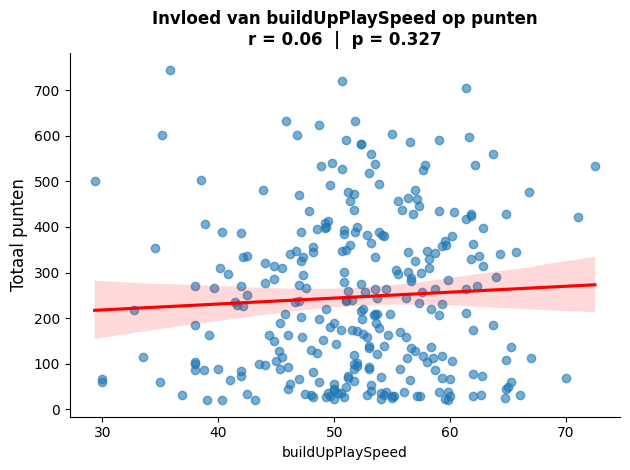

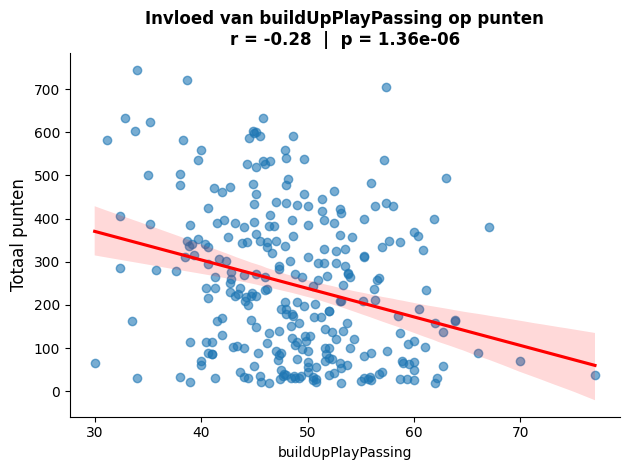

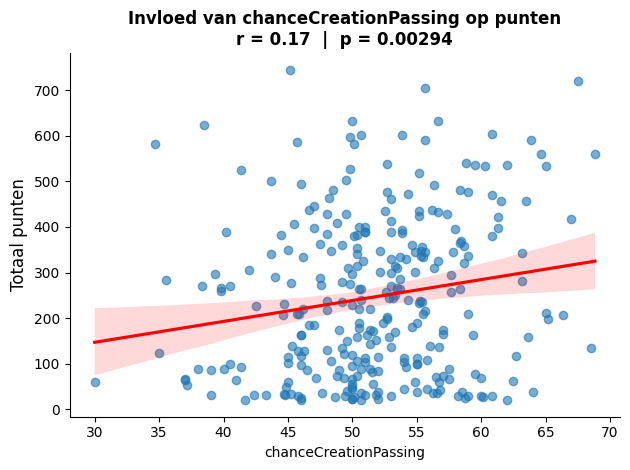

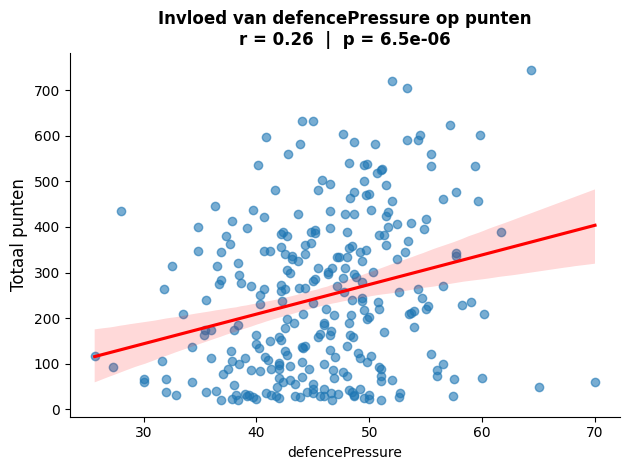

,variabele,r,p,n
1,buildUpPlayPassing,-0.280145,0.000001,288
3,defencePressure,0.262194,0.000007,288
2,chanceCreationPassing,0.174651,0.002940,288
0,buildUpPlaySpeed,0.057984,0.326806,288


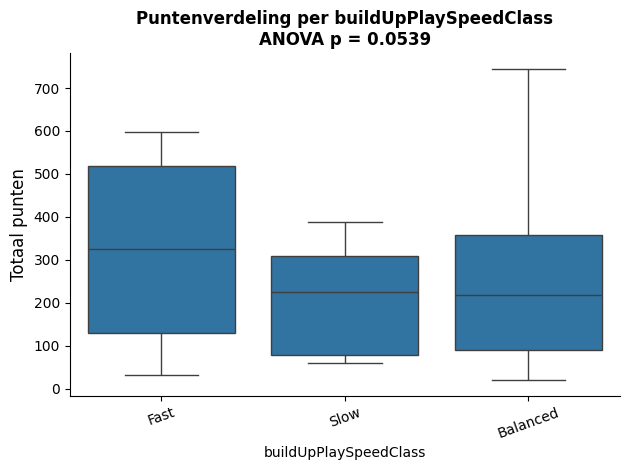

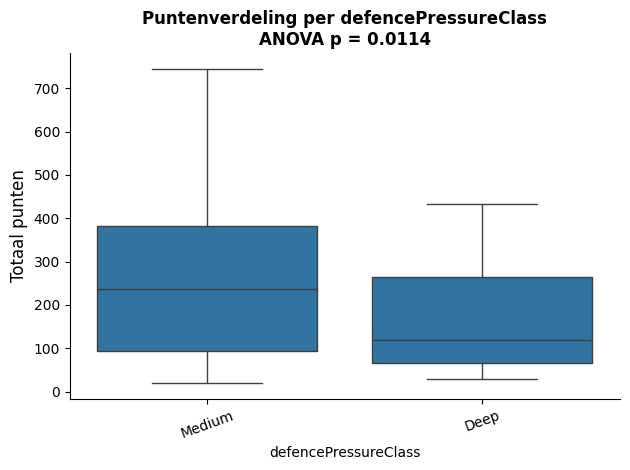

,variabele,anova_F,p,n
1,defencePressureClass,6.484923,0.011407,286
0,buildUpPlaySpeedClass,2.950375,0.053920,288


In [33]:
# Numerieke variabelen analyseren en resultaten opslaan
num_results = [plot_numeric_vs_points(data_2b, col)
               for col in num_vars if col in data_2b.columns]
num_summary = pd.DataFrame([r for r in num_results if r])

if not num_summary.empty:
    # Sorteren op sterkste correlatie (absoluut)
    num_summary = num_summary.sort_values('r', key=lambda s: s.abs(), ascending=False)
display(num_summary)

# Categoriale variabelen analyseren en resultaten opslaan
cat_results = [plot_categorical_vs_points(data_2b, col)
               for col in cat_vars if col in data_2b.columns]
cat_summary = pd.DataFrame([r for r in cat_results if r])
if not cat_summary.empty:
    cat_summary = cat_summary.sort_values('p')
display(cat_summary)


---
### 4.3 Interpretatie 

##### **4.3.1 Numerieke variabelen** 
Numerieken variabelen worden getoetst met een Pearson-correlatie (n = 288). De regressieplots tonen het verband tussen elke teameigenschap en het totaal aantal punten over alle seizoenen.

- **buildUpPlayPassing** heeft de sterkste correlatie: r = −0.28, p < 0.001. Teams die korter/lager passen scoren gemiddeld *meer* punten. Het verband is significant.
- **defencePressure** laat een positief verband zien: r = +0.26, p < 0.001. Hogere pressing hangt samen met meer punten. Ook significant.
- **chanceCreationPassing** heeft een zwak positief verband: r = +0.17, p = 0.003. Nog net significant, maar de spreiding in de plot is groot.
- **buildUpPlaySpeed** toont vrijwel geen verband: r = +0.06, p = 0.327. Speelsnelheid alleen voorspelt punten niet.

---

##### **4.3.2 Categoriale variabelen** worden getoetst met een eenweg ANOVA. De boxplots tonen de puntenverdeling per klasse.

- **defencePressureClass**: F = 6.48, p = 0.011. Er is een significant verschil tussen pressingsklassen — teams in de hogere pressingsklasse behalen aantoonbaar meer punten.
- **buildUpPlaySpeedClass**: F = 2.95, p = 0.054. Net boven de grens van p = 0.05 en daarmee niet significant. Het verschil in punten tussen snelheidsklassen kan op toeval berusten.

---